Loading data, importing libraries, and importing utils

In [32]:
from typing import *
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from models import SimpleModel
import torchvision.transforms.v2  as F
from torchviz import make_dot
import tqdm

from sklearn.svm import LinearSVC
from main import train,test,extract_features,train_with_patches,test_patches,extract_patch_features
from fisher_vector import neural_based_fisher
from IPython.display import clear_output
from torch.utils.data import TensorDataset, DataLoader

import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"

os.environ["CUDA_VISIBLE_DEVICES"]="0"

os.environ['JOBLIB_TEMP_FOLDER'] = '/home/msiau/workspace/jventosa/PostTFG/Master/project-1/Week2/joblib'


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)


#### MLP on small images

Entire Training

In [29]:
def train_simple_model(model,model_name,train_loader,test_loader):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 100

    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    best_test_loss = 10_000_000
    train_loss_at_best = 10_000_000
    best_test_accuracy =10_000_000
    best_epoch = 0
    for epoch in tqdm.tqdm(range(num_epochs), desc="TRAINING THE MODEL"):
        train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            train_loss_at_best = train_accuracy
            best_test_accuracy = test_accuracy
            best_epoch = epoch+1
            torch.save(model.state_dict(), f"SimpleModel/{model_name}.pth")

        print(f"Epoch {epoch + 1}/{num_epochs} - "
                f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
                f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    return best_test_accuracy, train_loss_at_best, best_epoch

In [30]:
optimal_image_size = 16
transformation  = F.Compose([
                                F.ToImage(),
                                F.ToDtype(torch.float32, scale=True),
                                F.Resize(size=(optimal_image_size, optimal_image_size)),
                            ])

data_train = ImageFolder("../../datasets/C3/2526/places_reduced/train", transform=transformation)
data_test = ImageFolder("../../datasets/C3/2526/places_reduced/val", transform=transformation) 

train_loader = DataLoader(data_train, batch_size=256, pin_memory=True, shuffle=True, num_workers=8)
test_loader = DataLoader(data_test, batch_size=128, pin_memory=True, shuffle=False, num_workers=8)

#### SVM on layers from model

We will use the same model as last cell, and try some taking features from each layer

In [31]:
model = SimpleModel(input_d=C*16*16,hidden_layers_n=1, hidden_d=256, output_d=11)

model = model.to(device)
model.load_state_dict(torch.load(f"SimpleModel/768_input_1_layers_256_dimension.pth", weights_only=True))

train_feats, train_labels = extract_features(model, train_loader, device, layer_id)
test_feats, test_labels = extract_features(model, test_loader, device, layer_id)

svm = LinearSVC(C=1.0)
svm.fit(train_feats, train_labels)
svm_acc = svm.score(test_feats, test_labels)

print(f"SVM accuracy using layer {layer_id}: {svm_acc:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'SimpleModel/768_input_1_layers_256_dimension.pth'

#### Patch predictions joined

In [ ]:
C, H, W = np.array(data_train[0][0]).shape

patch_size = int(H / 4)

hidden_layers_n = 2

model = SimpleModel(input_d=C*patch_size*patch_size,hidden_layers_n=hidden_layers_n, hidden_d=300, output_d=11)


model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

best_test_loss = 10_000_000

for epoch in tqdm.tqdm(range(num_epochs), desc="TRAINING THE PATCH BASED MODEL"):
    train_loss, train_accuracy = train_with_patches(model, train_loader, criterion, optimizer, device,patch_size)
    test_loss, test_accuracy = test_patches(model, test_loader, criterion, device,patch_size)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        os.makedirs(f"PatchModel_{patch_size}",exist_ok=True)
        torch.save(model.state_dict(), f"PatchModel_{patch_size}/BestWeights.pth")

    print(f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
            f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

/tmp/ipykernel_1373809/2592268092.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  C, H, W = np.array(data_train[0][0]).shape
TRAINING THE PATCH BASED MODEL:   5%|▌         | 1/20 [00:02<00:48,  2.54s/it]

Epoch 1/20 - Train Loss: 2.3404, Train Accuracy: 0.1414, Test Loss: 2.2751, Test Accuracy: 0.1645


TRAINING THE PATCH BASED MODEL:  10%|█         | 2/20 [00:05<00:47,  2.62s/it]

Epoch 2/20 - Train Loss: 2.2176, Train Accuracy: 0.2051, Test Loss: 2.1717, Test Accuracy: 0.2309


TRAINING THE PATCH BASED MODEL:  15%|█▌        | 3/20 [00:07<00:44,  2.62s/it]

...

Epoch 18/20 - Train Loss: 1.9820, Train Accuracy: 0.2964, Test Loss: 1.9706, Test Accuracy: 0.2986


TRAINING THE PATCH BASED MODEL:  95%|█████████▌| 19/20 [00:51<00:02,  2.74s/it]

Epoch 19/20 - Train Loss: 1.9546, Train Accuracy: 0.3074, Test Loss: 1.9980, Test Accuracy: 0.3005


TRAINING THE PATCH BASED MODEL: 100%|██████████| 20/20 [00:53<00:00,  2.69s/it]

Epoch 20/20 - Train Loss: 1.9578, Train Accuracy: 0.3032, Test Loss: 1.9419, Test Accuracy: 0.3105


In [ ]:
C, H, W = np.array(data_train[0][0]).shape

patch_size = int(H / 4)

hidden_layers_n = 2

model = SimpleModel(input_d=C*patch_size*patch_size,hidden_layers_n=hidden_layers_n, hidden_d=300, output_d=11)

model = model.to(device)
model.load_state_dict(torch.load(f"PatchModel_{patch_size}/BestWeights.pth", weights_only=True))

criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy = test_patches(model, test_loader, criterion, device,patch_size)

print(test_loss,test_accuracy)

/tmp/ipykernel_1373809/1734823305.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  C, H, W = np.array(data_train[0][0]).shape


1.9418735807592218 0.3104545454545454


#### Passing patch features to BOVW

Our best method was ___ 

In [ ]:


C, H, W = np.array(data_train[0][0]).shape

patch_size = int(H / 4)

hidden_layers_n = 2

model = SimpleModel(input_d=C*patch_size*patch_size,hidden_layers_n=hidden_layers_n, hidden_d=300, output_d=11)

model = model.to(device)
model.load_state_dict(torch.load(f"PatchModel_{patch_size}/BestWeights.pth", weights_only=True))


for layer_id in range(hidden_layers_n+1):
    train_feats, train_labels = extract_patch_features(model, train_loader, device, layer_id,patch_size)
    test_feats, test_labels = extract_patch_features(model, test_loader, device, layer_id,patch_size)
    print(train_feats.shape)
    print(train_labels.shape)
    acc , _ = neural_based_fisher(train_feats, test_feats, train_labels, test_labels)

    print(f"BOVW accuracy using layer {layer_id}: {acc:.4f}")

/tmp/ipykernel_1373809/2650827661.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  C, H, W = np.array(data_train[0][0]).shape


(8700, 16, 300)
(8700,)
y
Fitting GMM with K=128, cov_type=diag on 2000 descriptors...
Initialization 0
Initialization converged.


Computing Fisher Vectors (Parallel): 100%|██████████| 8700/8700 [00:31<00:00, 279.54it/s]


Extracting descriptors for test set...


Computing Fisher Vectors (Parallel): 100%|██████████| 2200/2200 [00:03<00:00, 585.17it/s]


mamaMia
pizzeria


PicklingError: Could not pickle the task to send it to the workers.

In [35]:

# BEST CONFIGURATION

BEST_IMAGE_SIZE = 16
BEST_HIDDEN_LAYERS = 1
BEST_HIDDEN_DIM = 256
BEST_PATCH_SIZE = 8

# Update transforms
transformation = F.Compose([
    F.ToImage(),
    F.ToDtype(torch.float32, scale=True),
    F.Resize(size=(BEST_IMAGE_SIZE, BEST_IMAGE_SIZE)),
])

data_train.transform = transformation
data_test.transform = transformation

C, H, W = data_train[0][0].shape
input_d = C * H * W
num_classes = len(data_train.classes)

In [36]:
activation_results = {}

activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.1),
    "Tanh": nn.Tanh()
}

for name, act in activations.items():
    print(f"Activation: {name}")

    model = SimpleModel(
        input_d=input_d,
        hidden_d=BEST_HIDDEN_DIM,
        hidden_layers_n=BEST_HIDDEN_LAYERS,
        output_d=num_classes
    )
    model.activation = act
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for _ in range(3):
        train(model, train_loader, criterion, optimizer, device)

    _, acc = test(model, test_loader, criterion, device)
    activation_results[name] = acc

Activation: ReLU
Activation: LeakyReLU
Activation: Tanh


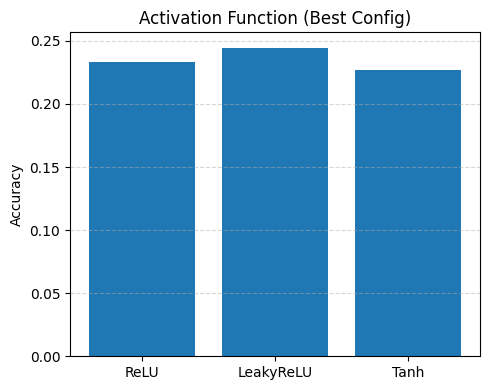

In [37]:
plt.figure(figsize=(5,4))
plt.bar(activation_results.keys(), activation_results.values())
plt.ylabel("Accuracy")
plt.title("Activation Function (Best Config)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [38]:
optimizer_results = {}

optimizers = {
    "Adam": lambda p: torch.optim.Adam(p, lr=1e-3),
    "SGD": lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
    "AdamW": lambda p: torch.optim.AdamW(p, lr=1e-3)
}

for name, opt_fn in optimizers.items():
    print(f"Optimizer: {name}")

    model = SimpleModel(
        input_d=input_d,
        hidden_d=BEST_HIDDEN_DIM,
        hidden_layers_n=BEST_HIDDEN_LAYERS,
        output_d=num_classes
    ).to(device)

    optimizer = opt_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()

    for _ in range(3):
        train(model, train_loader, criterion, optimizer, device)

    _, acc = test(model, test_loader, criterion, device)
    optimizer_results[name] = acc


Optimizer: Adam
Optimizer: SGD
Optimizer: AdamW


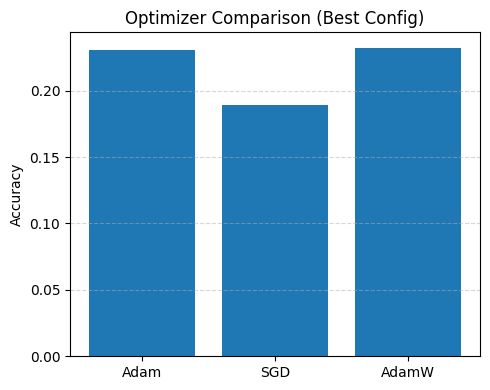

In [39]:
plt.figure(figsize=(5,4))
plt.bar(optimizer_results.keys(), optimizer_results.values())
plt.ylabel("Accuracy")
plt.title("Optimizer Comparison (Best Config)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [41]:
layer_results = {}

for layer_id in [1, 2]:
    print(f"SVM on layer {layer_id}")

    train_feats, train_labels = extract_features(
        model, data_train, layer_id
    )
    test_feats, test_labels = extract_features(
        model, data_test, layer_id
    )

    svm = LinearSVC(max_iter=5000)
    svm.fit(train_feats, train_labels)

    layer_results[f"Layer {layer_id}"] = svm.score(test_feats, test_labels)


SVM on layer 1


TypeError: extract_features() missing 1 required positional argument: 'layer_id'

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(layer_results.keys(), layer_results.values())
plt.ylabel("Accuracy")
plt.title("Layer Descriptor Comparison (Best Config)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


NameError: name 'layer_results' is not defined

<Figure size 500x400 with 0 Axes>

In [43]:
def extract_patches_fixed(img, patch_size=BEST_PATCH_SIZE):
    patches = []
    for i in range(0, BEST_IMAGE_SIZE, patch_size):
        for j in range(0, BEST_IMAGE_SIZE, patch_size):
            patch = img[:, i:i+patch_size, j:j+patch_size]
            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patches.append(patch)
    return patches


aggregation_results = {}

for agg in ["mean", "max"]:
    correct, total = 0, 0

    for img, label in data_test:
        patches = extract_patches_fixed(img)
        logits = []

        for p in patches:
            with torch.no_grad():
                out = model(p.unsqueeze(0).to(device))
            logits.append(out.squeeze(0))

        logits = torch.stack(logits)

        pred = logits.mean(dim=0) if agg == "mean" else logits.max(dim=0).values

        correct += int(pred.argmax().item() == label)
        total += 1

    aggregation_results[agg] = correct / total


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

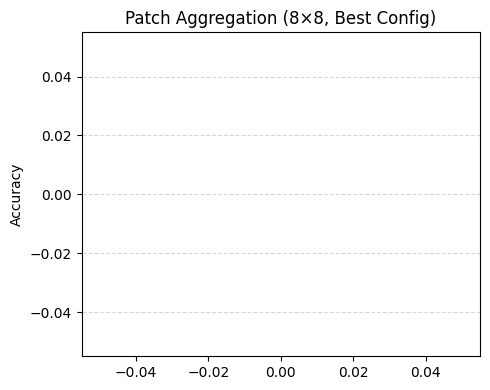

In [44]:
plt.figure(figsize=(5,4))
plt.bar(aggregation_results.keys(), aggregation_results.values())
plt.ylabel("Accuracy")
plt.title("Patch Aggregation (8×8, Best Config)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
final_results = {
    "End-to-end": end2end_acc,
    "Patch (mean)": aggregation_results["mean"],
    "Best SVM layer": max(layer_results.values()),
    "BoW + SVM": bow_acc
}

plt.figure(figsize=(6,4))
plt.bar(final_results.keys(), final_results.values())
plt.ylabel("Accuracy")
plt.title("Final Comparison (Best Configuration)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
